# 子图
- 子图可以作为父图的一个节点，也可以是在父图节点里被invoke，但是invoke注意不要链式调用，否则获取图时会渲染不出来
- 父图编译时传入checkpointer,能传递给子图存储。get_state_history(config=config)获取到检查点快照后可以看到子图的tasks[i].state中记录了thread_id和checkpoint_ns，thread_id和父图thread_id一样，但checkpoint_ns遵循`<子图所属父节点的名称>:<子图所属父图任务ID>`的格式，如果有嵌套子图，则遵循：`call_subgraph:<task_id_1>|call_inner_graph:<task_id_2>` （用`|`拼接）

## 父图内调用子图

============================== ->   原始文本   <- ==============================
   LangGraph 真有意思        
============================== -> 清洗后的文本 <- ==============================
LangGraph 真有意思。


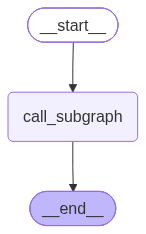

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from sqlalchemy.orm.attributes import get_state_history


# 构建子图
class SubgraphState(TypedDict):
    raw_text: str # 未清洗文本
    stripped_text: str # 去除收尾空格的文本
    punctuated_text: str # 句尾添加句号的文本

def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "stripped_text": stripped_text
    }

def subgraph_punctuate_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + "。"

    return {
        "punctuated_text": punctuated_text
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

subgraph = builder.compile()

# 构建父图
class ParentState(TypedDict):
    input_text: str # 输入的未清洗的文本
    cleaned_text: str # 清洗后的文本

def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]

    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)

builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

parent_graph = builder.compile()

input_text = "   LangGraph 真有意思        "
res = parent_graph.invoke({"input_text": input_text})
cleaned_text = res["cleaned_text"]
print("=" * 30, "->   原始文本   <-", "=" * 30)
print(input_text)
print("=" * 30, "-> 清洗后的文本 <-", "=" * 30)
print(cleaned_text)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        # xray=True显示子图细节，否则只显示父图单个节点（自动解析并递归获取子图的拓扑结构）
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

## 子图作为父图的节点

============================== ->   原始文本   <- ==============================
   LangGraph 真有意思        
============================== -> 清洗后的文本 <- ==============================
LangGraph 真有意思。


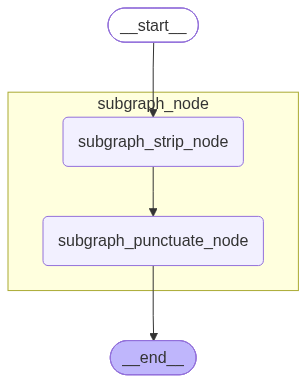

In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 定义全局共享状态
class OverAllState(TypedDict):
    raw_text: str # 未清洗文本
    cleaned_text: str # 清洗后的文本

# 构建子图
def subgraph_strip_node(state: OverAllState) -> OverAllState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "cleaned_text": stripped_text
    }

def subgraph_punctuate_node(state: OverAllState) -> OverAllState:
    cleaned_text = state["cleaned_text"]
    punctuated_text = cleaned_text + "。"

    return {
        "cleaned_text": punctuated_text
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

subgraph = builder.compile()

# 构建父图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_node", subgraph)

builder.add_edge(START, "subgraph_node")
builder.add_edge("subgraph_node", END)

parent_graph = builder.compile()

raw_text = "   LangGraph 真有意思        "
res = parent_graph.invoke({"raw_text": raw_text})
cleaned_text = res["cleaned_text"]
print("=" * 30, "->   原始文本   <-", "=" * 30)
print(raw_text)
print("=" * 30, "-> 清洗后的文本 <-", "=" * 30)
print(cleaned_text)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        # .get_graph()
        .draw_mermaid_png()
    )
)

## 查看子图

In [6]:
list(parent_graph.get_subgraphs())

[('subgraph_node',
  <langgraph.graph.state.CompiledStateGraph at 0x2f83511b5c0>)]

## 子图持久化

============================== ->   原始文本   <- ==============================
   LangGraph 真有意思        
============================== -> 清洗后的文本 <- ==============================
LangGraph 真有意思。


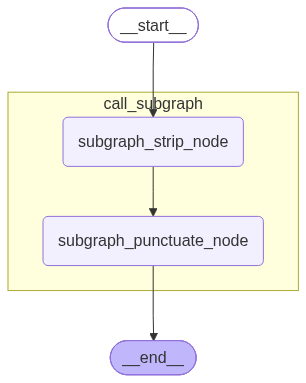

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str # 未清洗文本
    stripped_text: str # 去除收尾空格的文本
    punctuated_text: str # 句尾添加句号的文本

def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "stripped_text": stripped_text
    }

def subgraph_punctuate_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + "。"

    return {
        "punctuated_text": punctuated_text
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

subgraph = builder.compile()

# 构建父图
class ParentState(TypedDict):
    input_text: str # 输入的未清洗的文本
    cleaned_text: str # 清洗后的文本

def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]

    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)

builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer=InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

input_text = "   LangGraph 真有意思        "
config={"configurable": {"thread_id": "observe_checkpoint_1"}}
res = parent_graph.invoke(
    {"input_text": input_text},
    config=config
)
cleaned_text = res["cleaned_text"]
print("=" * 30, "->   原始文本   <-", "=" * 30)
print(input_text)
print("=" * 30, "-> 清洗后的文本 <-", "=" * 30)
print(cleaned_text)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

In [10]:
from rich import print as rprint
parent_state_history_list = list(parent_graph.get_state_history(config=config))
rprint(parent_state_history_list)

[
    StateSnapshot(
        values={'input_text': '   LangGraph 真有意思        ', 'cleaned_text': 'LangGraph 真有意思。'},
        next=(),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197bd6-4030-6c4d-8001-4065f1210838'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-08-14T08:51:50.773041+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197bd6-4027-6e76-8000-b98cfa5610d9'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'input_text': '   LangGraph 真有意思        '},
        next=('call_subgraph',),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197bd6-4027-6e76-8000-b98cfa5610d9'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-14T08:51:50.769408+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197bd6-4025-6eaf-bfff-08a0d124b9cb'
            }
        },
        tasks=(
            PregelTask(
                id='afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                name='call_subgraph',
                path=('__pregel_pull', 'call_subgraph'),
                error=None,
                interrupts=(),
                state={
                    'configurable': {
                        'thread_id': 'observe_checkpoint_1',
                        'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb'
                    }
                },
                result={'cleaned_text': 'LangGraph 真有意思。'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197bd6-4025-6eaf-bfff-08a0d124b9cb'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-14T08:51:50.768599+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='9af7b59f-7ecc-e489-19a6-311b4664b386',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={'input_text': '   LangGraph 真有意思        '}
            ),
        ),
        interrupts=()
    )
]

## 子图快照列表

In [15]:
# 定位到子图所属父节点
subgraph_config = parent_state_history_list[-2].tasks[0].state
subgraph_history = list(parent_graph.get_state_history(config=subgraph_config))
rprint(subgraph_history)

[
    StateSnapshot(
        values={
            'raw_text': '   LangGraph 真有意思        ',
            'stripped_text': 'LangGraph 真有意思',
            'punctuated_text': 'LangGraph 真有意思。'
        },
        next=(),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                'checkpoint_id': '1f197bd6-402e-6fb6-8002-f587051777f2',
                'checkpoint_map': {
                    '': '1f197bd6-4027-6e76-8000-b98cfa5610d9',
                    'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb': '1f197bd6-402e-6fb6-8002-f587051777f2'
                }
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {'': '1f197bd6-4027-6e76-8000-b98cfa5610d9'}},
        created_at='2026-08-14T08:51:50.772308+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                'checkpoint_id': '1f197bd6-402d-69e6-8001-4fd5711a5d96',
                'checkpoint_map': {
                    '': '1f197bd6-4027-6e76-8000-b98cfa5610d9',
                    'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb': '1f197bd6-402d-69e6-8001-4fd5711a5d96'
                }
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'raw_text': '   LangGraph 真有意思        ', 'stripped_text': 'LangGraph 真有意思'},
        next=('subgraph_punctuate_node',),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                'checkpoint_id': '1f197bd6-402d-69e6-8001-4fd5711a5d96',
                'checkpoint_map': {
                    '': '1f197bd6-4027-6e76-8000-b98cfa5610d9',
                    'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb': '1f197bd6-402d-69e6-8001-4fd5711a5d96'
                }
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {'': '1f197bd6-4027-6e76-8000-b98cfa5610d9'}},
        created_at='2026-08-14T08:51:50.771751+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                'checkpoint_id': '1f197bd6-402a-6f16-8000-9c00623c8608',
                'checkpoint_map': {
                    '': '1f197bd6-4027-6e76-8000-b98cfa5610d9',
                    'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb': '1f197bd6-402a-6f16-8000-9c00623c8608'
                }
            }
        },
        tasks=(
            PregelTask(
                id='204c9c64-684b-ad91-ef89-028bc9519006',
                name='subgraph_punctuate_node',
                path=('__pregel_pull', 'subgraph_punctuate_node'),
                error=None,
                interrupts=(),
                state=None,
                result={'punctuated_text': 'LangGraph 真有意思。'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'raw_text': '   LangGraph 真有意思        '},
        next=('subgraph_strip_node',),
        config={
            'configurable': {
                'thread_id': 'observe_checkpoint_1',
                'checkpoint_ns': 'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb',
                'checkpoint_id': '1f197bd6-402a-6f16-8000-9c00623c8608',
                'checkpoint_map': {
                    '': '1f197bd6-4027-6e76-8000-b98cfa5610d9',
                    'call_subgraph:afb1ebeb-77c0-e7bd-dce7-dc5af5890bfb': '1f197bd6-402a-6f16-8000-9c00623c8608'
                }
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {'': '1f197bd6-4027-6e76-8000-b98cfa5610d9'}},
        created_at='2026-08-14